# 🔥 mBERT — Optimized Training (Google Colab GPU)

### ✅ Before running:
1. **Runtime → Change runtime type → T4 GPU** (free tier is fine)
2. Upload your `traindataset.xlsx` when prompted **OR** save it to Google Drive first
3. Run all cells top to bottom (`Runtime → Run all`)

**Expected time on T4 GPU:** ~30–60 minutes total


In [7]:
# ── Step 1: Verify GPU is available ─────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print('✅ GPU detected!')
    print(result.stdout[:500])
else:
    print('❌ No GPU found!')
    print('   Go to: Runtime → Change runtime type → T4 GPU  then re-run')
    raise SystemExit('Please enable GPU first.')

✅ GPU detected!
Thu Feb 26 13:55:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


In [8]:
# ── Step 2: Install / upgrade dependencies ───────────────────────────────────
!pip install -q --upgrade transformers datasets scikit-learn openpyxl accelerate

In [9]:
# ── Step 3: Upload your dataset ──────────────────────────────────────────────
# OPTION A — Upload directly from your PC (simple, recommended)
from google.colab import files
import os

DATASET_FILE = 'traindataset.xlsx'

if not os.path.exists(DATASET_FILE):
    print('Please select your traindataset.xlsx file to upload:')
    uploaded = files.upload()          # opens a file picker
    DATASET_FILE = list(uploaded.keys())[0]
    print(f'Uploaded: {DATASET_FILE}')
else:
    print(f'Found existing file: {DATASET_FILE}')

# ── OPTION B (alternative) — Mount Google Drive ──────────────────────────────
# If you saved the file to Google Drive, uncomment the lines below instead:
# from google.colab import drive
# drive.mount('/content/drive')
# DATASET_FILE = '/content/drive/MyDrive/traindataset.xlsx'   # adjust path

Found existing file: traindataset.xlsx


In [10]:
# ── Step 4: Imports & Config ─────────────────────────────────────────────────
import os, math, warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    f1_score, accuracy_score, precision_score, recall_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback,
    DataCollatorWithPadding, set_seed,
    get_cosine_schedule_with_warmup
)
from datasets import Dataset
import torch.nn as nn
from torch.optim import AdamW

# ── Hyperparameters ───────────────────────────────────────────────────────────
SEED          = 42
HF_MODEL      = 'bert-base-multilingual-cased'
OUTPUT_DIR    = '/content/mbert_saved'

EPOCHS        = 10          # early stopping will cut this short
LR            = 2e-5
BATCH         = 32          # GPU can handle larger batches
VAL_SPLIT     = 0.20
WARMUP_RATIO  = 0.10
WEIGHT_DECAY  = 0.01
MAX_GRAD_NORM = 1.0
MAX_LEN       = 256
ES_PATIENCE   = 3
LLRD_FACTOR   = 0.9

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_FP16 = (DEVICE == 'cuda')

set_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'FP16   : {USE_FP16}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
FP16   : True


In [11]:
# ── Step 5: Load & Preprocess Dataset ────────────────────────────────────────
df = pd.read_excel(DATASET_FILE)
df = df[['Questions', 'Genarated__Answer', 'label']].dropna()
df['label']         = df['label'].astype(int)
df['question_text'] = df['Questions'].astype(str)
df['answer_text']   = df['Genarated__Answer'].astype(str)

print(f'Total samples : {len(df)}')
print('Label dist    :', Counter(df['label']))

Total samples : 7043
Label dist    : Counter({0: 3982, 1: 3061})


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Token p95=56  →  using EFFECTIVE_MAX_LEN=56


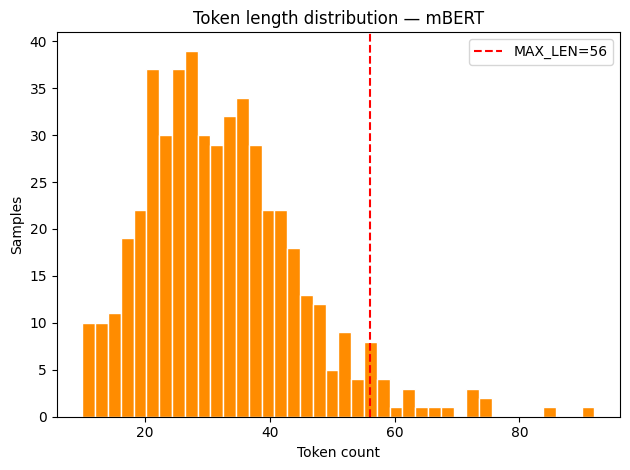

In [12]:
# ── Step 6: Tokenizer & Optimal Max Length ────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(HF_MODEL)

combined = df['question_text'] + ' ' + df['answer_text']
sample_lens = combined.sample(min(500, len(df)), random_state=SEED)\
    .apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))
p95 = int(np.percentile(sample_lens, 95))
EFFECTIVE_MAX_LEN = min(MAX_LEN, p95, 512)
print(f'Token p95={p95}  →  using EFFECTIVE_MAX_LEN={EFFECTIVE_MAX_LEN}')

plt.hist(sample_lens, bins=40, color='darkorange', edgecolor='white')
plt.axvline(EFFECTIVE_MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={EFFECTIVE_MAX_LEN}')
plt.xlabel('Token count'); plt.ylabel('Samples')
plt.title('Token length distribution — mBERT')
plt.legend(); plt.tight_layout(); plt.show()

In [13]:
# ── Step 7: Stratified Split + Tokenisation ───────────────────────────────────
questions  = df['question_text'].tolist()
answers    = df['answer_text'].tolist()
labels_all = df['label'].tolist()

idx = list(range(len(df)))
train_idx, val_idx = train_test_split(
    idx, test_size=VAL_SPLIT, stratify=labels_all, random_state=SEED
)
train_q      = [questions[i]  for i in train_idx]
train_a      = [answers[i]    for i in train_idx]
train_labels = [labels_all[i] for i in train_idx]
val_q        = [questions[i]  for i in val_idx]
val_a        = [answers[i]    for i in val_idx]
val_labels   = [labels_all[i] for i in val_idx]

print(f'Train={len(train_q)}  Val={len(val_q)}')
print('Train dist:', Counter(train_labels))
print('Val dist  :', Counter(val_labels))

# text_pair → [CLS] Question [SEP] Answer [SEP]  (proper BERT segment encoding)
def tokenize(batch):
    return tokenizer(
        batch['question'], batch['answer'],
        padding=False, truncation=True, max_length=EFFECTIVE_MAX_LEN
    )

train_dataset = Dataset.from_dict({'question': train_q, 'answer': train_a, 'label': train_labels})
val_dataset   = Dataset.from_dict({'question': val_q,   'answer': val_a,   'label': val_labels})
train_dataset = train_dataset.map(tokenize, batched=True, remove_columns=['question', 'answer'])
val_dataset   = val_dataset.map(tokenize,   batched=True, remove_columns=['question', 'answer'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Train=5634  Val=1409
Train dist: Counter({0: 3185, 1: 2449})
Val dist  : Counter({0: 797, 1: 612})


Map:   0%|          | 0/5634 [00:00<?, ? examples/s]

Map:   0%|          | 0/1409 [00:00<?, ? examples/s]

In [14]:
# ── Step 8: Class Weights ─────────────────────────────────────────────────────
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print(f'Class weights: {class_weights}')

Class weights: [0.8844584  1.15026541]


In [15]:
# ── Step 9: Metrics ───────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy':  float(accuracy_score(labels, preds)),
        'f1':        float(f1_score(labels, preds, average='weighted')),
        'precision': float(precision_score(labels, preds, average='weighted', zero_division=0)),
        'recall':    float(recall_score(labels, preds, average='weighted', zero_division=0)),
    }

In [16]:
# ── Step 10: Layer-wise LR Decay + Custom Trainer ────────────────────────────
def get_llrd_param_groups(model, base_lr, decay_factor):
    encoder = getattr(model, 'bert', None) or getattr(model, 'electra', None)
    if encoder is None:
        return None
    layers   = encoder.encoder.layer
    n_layers = len(layers)
    no_decay  = ['bias', 'LayerNorm.weight']
    groups    = []
    head = [p for n, p in model.named_parameters() if 'bert' not in n and 'electra' not in n]
    groups.append({'params': head, 'lr': base_lr, 'weight_decay': WEIGHT_DECAY})
    emb_lr = base_lr * (decay_factor ** n_layers)
    emb_nd = [p for n, p in encoder.embeddings.named_parameters() if not any(nd in n for nd in no_decay)]
    emb_d  = [p for n, p in encoder.embeddings.named_parameters() if     any(nd in n for nd in no_decay)]
    groups += [{'params': emb_nd, 'lr': emb_lr, 'weight_decay': WEIGHT_DECAY},
               {'params': emb_d,  'lr': emb_lr, 'weight_decay': 0.0}]
    for i, layer in enumerate(layers):
        lr_i = base_lr * (decay_factor ** (n_layers - 1 - i))
        nd_p = [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)]
        d_p  = [p for n, p in layer.named_parameters() if     any(nd in n for nd in no_decay)]
        groups += [{'params': nd_p, 'lr': lr_i, 'weight_decay': WEIGHT_DECAY},
                   {'params': d_p,  'lr': lr_i, 'weight_decay': 0.0}]
    return groups


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=class_weights_tensor)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

    def create_optimizer(self):
        groups = get_llrd_param_groups(self.model, LR, LLRD_FACTOR)
        if groups is None:
            return super().create_optimizer()
        self.optimizer = AdamW(groups)
        return self.optimizer

    def create_scheduler(self, num_training_steps, optimizer=None):
        if optimizer is None:
            optimizer = self.optimizer
        ws = math.ceil(num_training_steps * WARMUP_RATIO)
        self.lr_scheduler = get_cosine_schedule_with_warmup(
            optimizer, num_warmup_steps=ws, num_training_steps=num_training_steps)
        return self.lr_scheduler

In [17]:
# ── Step 11: Load Model & Train ───────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(HF_MODEL, num_labels=2).to(DEVICE)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    save_total_limit=2,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=BATCH,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    max_grad_norm=MAX_GRAD_NORM,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type='cosine',
    logging_dir=f'{OUTPUT_DIR}/logs',
    logging_steps=30,
    report_to='none',
    fp16=USE_FP16,
    dataloader_num_workers=2,
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=ES_PATIENCE)]
)

print('▶  Training started ...')
train_result = trainer.train()
print('\n✅ Training complete!')
print(train_result.metrics)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated

▶  Training started ...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.684780,0.670347,0.609652,0.604744,0.604632,0.609652
2,0.590720,0.627564,0.699077,0.679853,0.715330,0.699077
3,0.532593,0.566366,0.729595,0.717802,0.740682,0.729595
4,0.443934,0.543862,0.746629,0.743094,0.746627,0.746629
5,0.408989,0.580932,0.767211,0.762491,0.770411,0.767211
6,0.300234,0.581008,0.760823,0.760058,0.759946,0.760823
7,0.285299,0.620771,0.770050,0.768367,0.769363,0.770050
8,0.188815,0.745785,0.782115,0.779417,0.782938,0.782115
9,0.169105,0.739978,0.769340,0.767689,0.768620,0.769340
10,0.176180,0.751837,0.766501,0.764829,0.765730,0.766501


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Training complete!
{'train_runtime': 844.8068, 'train_samples_per_second': 66.69, 'train_steps_per_second': 2.095, 'total_flos': 1604839715502960.0, 'train_loss': 0.38177734660563495, 'epoch': 10.0}


In [18]:
# ── Step 12: Save Best Model ─────────────────────────────────────────────────
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'✅ Best model saved to {OUTPUT_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Best model saved to /content/mbert_saved


In [19]:
# ── Step 13: Final Evaluation ─────────────────────────────────────────────────
eval_res = trainer.evaluate()
print('\n── Validation Metrics ──')
for k, v in eval_res.items():
    print(f'  {k}: {round(v,4) if isinstance(v,float) else v}')


── Validation Metrics ──
  eval_loss: 0.7457
  eval_accuracy: 0.7821
  eval_f1: 0.7794
  eval_precision: 0.7829
  eval_recall: 0.7821
  eval_runtime: 2.1446
  eval_samples_per_second: 657.007
  eval_steps_per_second: 20.983
  epoch: 10.0



── Classification Report ──
                  precision    recall  f1-score   support

Hallucinated (0)       0.78      0.86      0.82       797
     Correct (1)       0.79      0.68      0.73       612

        accuracy                           0.78      1409
       macro avg       0.78      0.77      0.77      1409
    weighted avg       0.78      0.78      0.78      1409



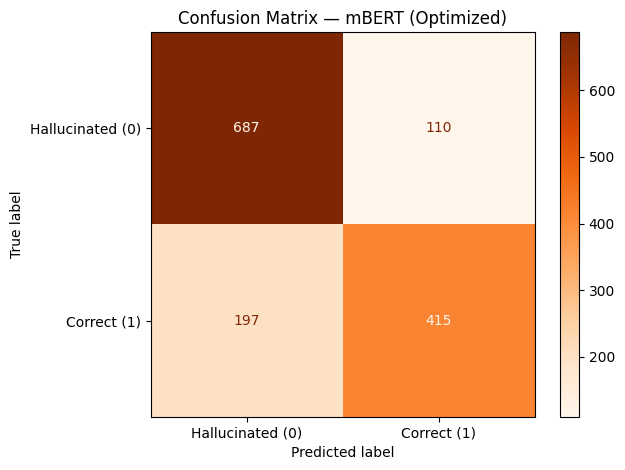

In [20]:
# ── Step 14: Confusion Matrix + Classification Report ────────────────────────
preds_out = trainer.predict(val_dataset)
y_true    = np.array(val_labels)
y_pred    = np.argmax(preds_out.predictions, axis=1)

print('\n── Classification Report ──')
print(classification_report(y_true, y_pred, target_names=['Hallucinated (0)', 'Correct (1)']))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Hallucinated (0)', 'Correct (1)']
                       ).plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix — mBERT (Optimized)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

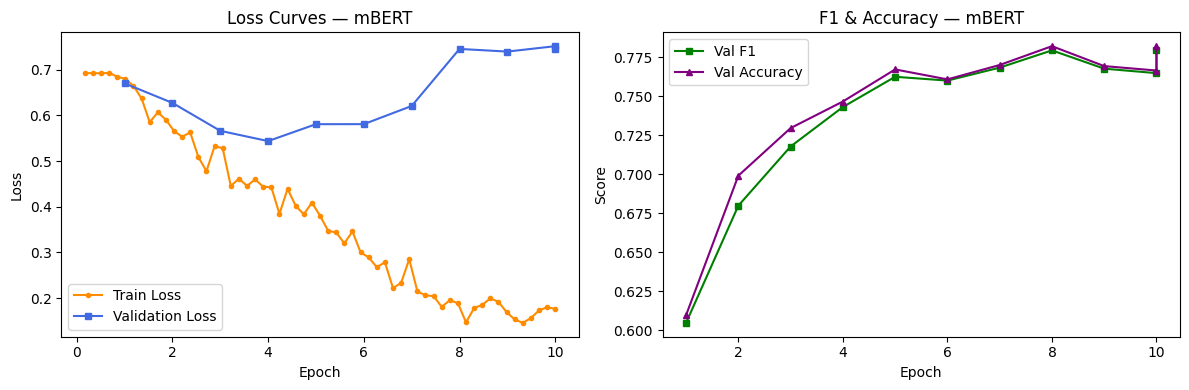

Plots saved.


In [21]:
# ── Step 15: Training Curves ──────────────────────────────────────────────────
log_history  = trainer.state.log_history
train_losses = [(h['epoch'], h['loss'])         for h in log_history if 'loss' in h and 'eval_loss' not in h]
eval_losses  = [(h['epoch'], h['eval_loss'])     for h in log_history if 'eval_loss' in h]
eval_f1s     = [(h['epoch'], h['eval_f1'])       for h in log_history if 'eval_f1' in h]
eval_accs    = [(h['epoch'], h['eval_accuracy']) for h in log_history if 'eval_accuracy' in h]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1 = axes[0]
if train_losses: ax1.plot(*zip(*train_losses), label='Train Loss',      marker='o', ms=3, color='darkorange')
if eval_losses:  ax1.plot(*zip(*eval_losses),  label='Validation Loss', marker='s', ms=4, color='royalblue')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves — mBERT'); ax1.legend()

ax2 = axes[1]
if eval_f1s:  ax2.plot(*zip(*eval_f1s),  label='Val F1',       marker='s', ms=4, color='green')
if eval_accs: ax2.plot(*zip(*eval_accs), label='Val Accuracy', marker='^', ms=4, color='purple')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('F1 & Accuracy — mBERT'); ax2.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()
print('Plots saved.')

In [22]:
# ── Step 16: Download Saved Model to your PC ─────────────────────────────────
import shutil
shutil.make_archive('/content/mbert_saved', 'zip', OUTPUT_DIR)

from google.colab import files
files.download('/content/mbert_saved.zip')
print('✅ Download started! Save the zip to your model/m-BERT/ folder.')

KeyboardInterrupt: 